###  Ejercicio 10 de Septiembre

Construyamos un árbol de decisión para Wine y para Iris

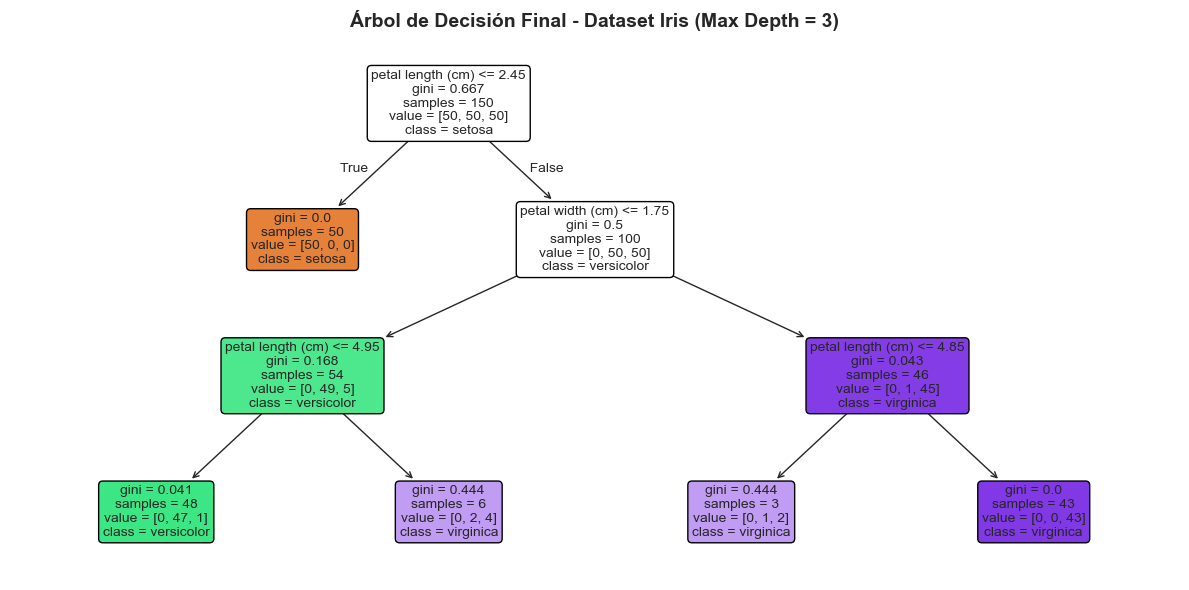

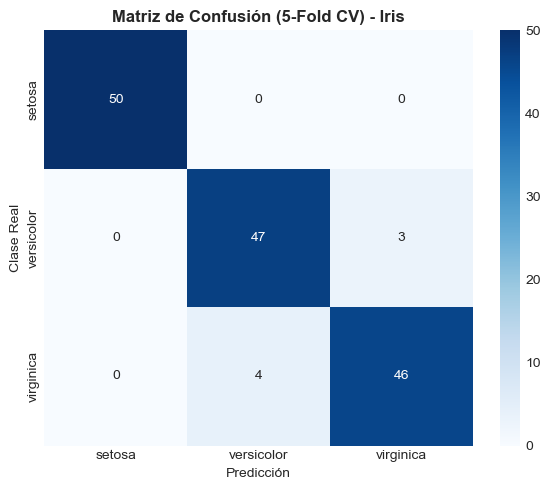

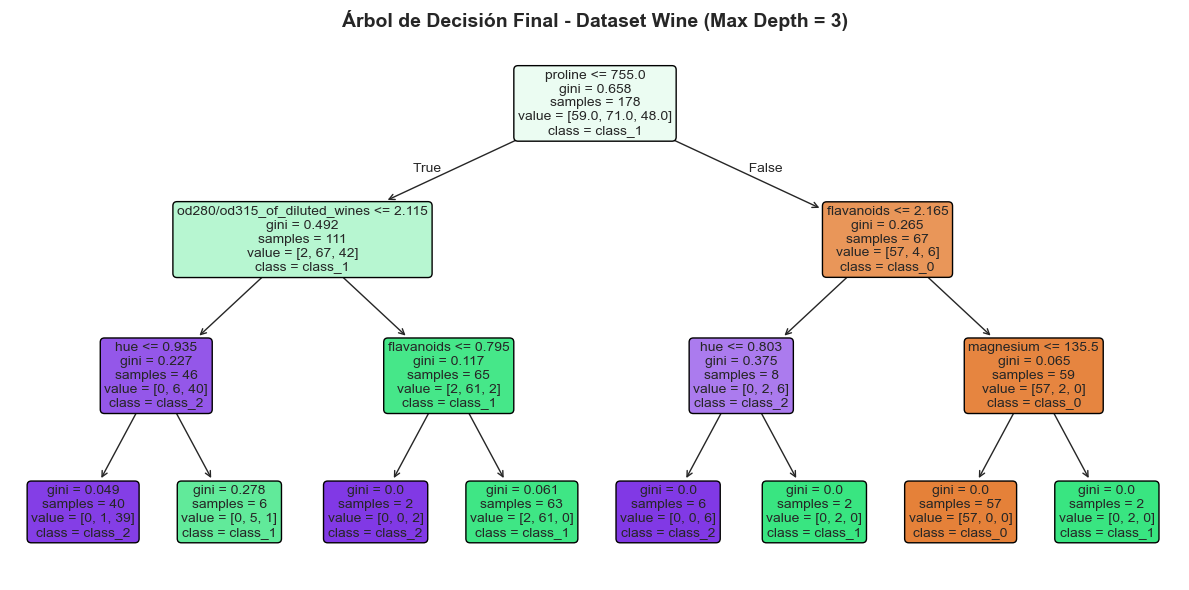

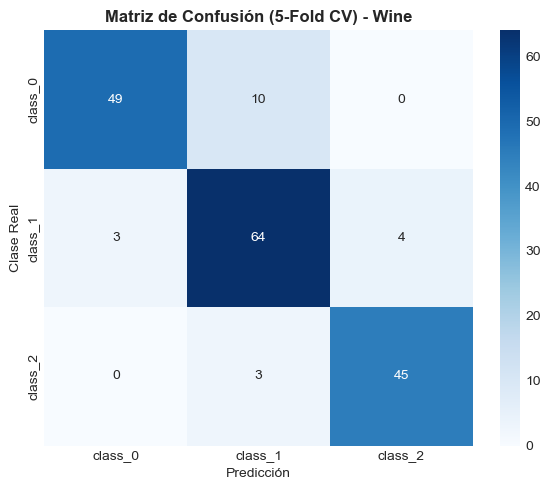

Dataset    | Accuracy   | Precision  | Recall     | F1-Score  
----------------------------------------------------------
Iris       | 0.9533     | 0.9578     | 0.9533     | 0.9533
Wine       | 0.8876     | 0.8914     | 0.8876     | 0.8855


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configuration general
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

datasets = {
    "Iris": load_iris(),
    "Wine": load_wine()
}

metrics_summary = {}

for name, ds in datasets.items():
    X, y = ds.data, ds.target
    feature_names = ds.feature_names
    target_names = ds.target_names
    
    # Modelo: Arbol de decision con profundidad controlada para evitar sobreajuste
    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    
    # 1. Evaluacion mediante K-Fold Cross Validation
    scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
    cv_results = cross_validate(clf, X, y, cv=kf, scoring=scoring)
    
    metrics_summary[name] = {
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Precision': np.mean(cv_results['test_precision_weighted']),
        'Recall': np.mean(cv_results['test_recall_weighted']),
        'F1-Score': np.mean(cv_results['test_f1_weighted'])
    }
    
    # 2. Matriz de confusion mediante predicciones en Cross-Validation
    y_pred_cv = cross_val_predict(clf, X, y, cv=kf)
    cm = confusion_matrix(y, y_pred_cv)
    
    # 3. Entrenamiento final para visualizacion de estructura
    clf.fit(X, y)
    
    # Grafico 1: Estructura del Arbol
    plt.figure(figsize=(12, 6))
    plot_tree(
        clf, 
        feature_names=feature_names, 
        class_names=target_names, 
        filled=True, 
        rounded=True, 
        fontsize=10
    )
    plt.title(f"Árbol de Decisión Final - Dataset {name} (Max Depth = 3)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Grafico 2: Matriz de Confusion (Acumulada en CV)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Matriz de Confusión ({k_folds}-Fold CV) - {name}", fontsize=12, fontweight='bold')
    plt.xlabel("Predicción")
    plt.ylabel("Clase Real")
    plt.tight_layout()
    plt.show()

# Print de resumen de metricas
print(f"{'Dataset':<10} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 58)
for name, m in metrics_summary.items():
    print(f"{name:<10} | {m['Accuracy']:.4f}     | {m['Precision']:.4f}     | {m['Recall']:.4f}     | {m['F1-Score']:.4f}")

Regresión lineal con 100 datos aleatorios (foto de la regresión en la carpeta (linear_regression.png))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configurar semilla para reproducibilidad
np.random.seed(42)

# 1. Generar 100 puntos (x, y) con ruido gaussiano
x = np.random.uniform(0, 10, 100).reshape(-1, 1)
# Modelo real: y = 2.5 * x + 5 + ruido
noise = np.random.normal(0, 2.5, size=(100, 1))
y = 2.5 * x + 5 + noise

# 2. Entrenar la regresión lineal
model = LinearRegression()
model.fit(x, y)

# Predicciones
y_pred = model.predict(x)

# Métricas
slope = model.coef_[0][0]
intercept = model.intercept_[0]
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"Pendiente (m): {slope:.4f}")
print(f"Intersección (b): {intercept:.4f}")
print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

# Visualización
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', alpha=0.6, label='Puntos con ruido (Datos)')
plt.plot(x, y_pred, color='red', linewidth=2, label=f'Línea de regresión: y = {slope:.2f}x + {intercept:.2f}')
plt.title('Regresión Lineal Simple con 100 Puntos Aleatorios')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('linear_regression.png')
plt.close()



Pendiente (m): 2.3851
Intersección (b): 5.5377
R^2: 0.9081
MSE: 5.0412
